# Tarea 3 De Procesamiento de Imagenes
El siguiente codigo  pertenece a Pablo Lores Saavedra e Ignacio Marambio Zamora.
Este codigo tiene fragmentos de codigo sacado de las siguientes fuentes citadas:

Ignacio Vicente Marambio Zamora. 2025. *Tarea 1* [Codigo Fuente](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672). UDP Canvas Tarea 1. [https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672).

mlacarrasco. 2025. *34_freq_noise.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py](https://github.com/mlacarrasco/image_processing/blob/main/34_freq_noise.py).

mlacarrasco. 2025. *11_binarizacion.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py).

## Programa Solicitado

### Parte 1
1. Utilice una imagen descargada de internet. De dicha imagen sólo utilice una sección de 512x512 píxeles (su imagen original debe ser igual o mayor a dicho tamaño).
2. Genere una imagen ruido frecuencial de 10Hz, una segunda imagen con 30Hz y una tercera imagen con 50Hz en forma vertical respectivamente (usted define la amplitud de la señal).
3. Genere una imagen que atenúe el ruido empleando filtros en la frecuencia para cada imagen del paso #2
### Parte 2
Genere una imagen con ruido empleando el siguiente código (no lo modifique). Luego desarrolle un
filtro en la frecuencia para reducir dicho ruido. Usted debe definir el filtro más apropiado.
``` python
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cameraman.png',cv2.IMREAD_GRAYSCALE)
m = img.shape[0]
delta = 15
V = np.fix(np.linspace(delta,m-delta,delta)).astype('uint8')
img[V,:] = img[V,:]+50
img[:,V] = img[:,V]+50
plt.imshow(img, cmap='gray')
plt.show()
```

### Contexto
El objetivo de esta tarea es aplicar técnicas de procesamiento de imágenes para generar ruido frecuencial, atenuarlo mediante filtros y trabajar con imágenes con ruido. Se utilizarán bibliotecas como OpenCV, NumPy y Matplotlib para manipular y visualizar las imágenes.
De una imagen descargada de internet llamada stonks.png se le aplicará un filtro de ruido frecuencial y se generarán imágenes con diferentes frecuencias de ruido. 
Luego, se aplicarán filtros para atenuar dicho ruido.

Se presentara la imagen original stonks.png, antes de aplicar el ruido frecuencial cortada a 512x512 píxeles.

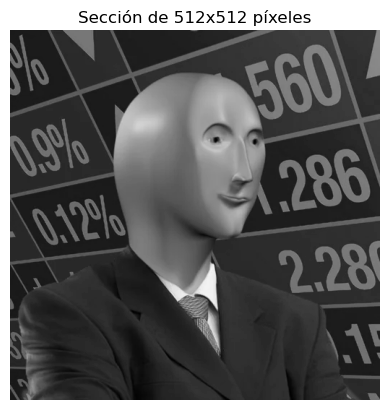

In [162]:
import cv2
import matplotlib.pyplot as plt
try:
    A = cv2.imread('stonks.png', 0)
    # Se selecciona una sección de 512x512 píxeles desde la esquina superior izquierda
    A = A[:512, :512]
    plt.imshow(A, cmap='gray')
    plt.title('Sección de 512x512 píxeles')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error: {e}")

Se utilizará una función sobre la imagen antes mencionada para generar imágenes con ruido frecuencial a 10Hz, 30Hz y 50Hz.

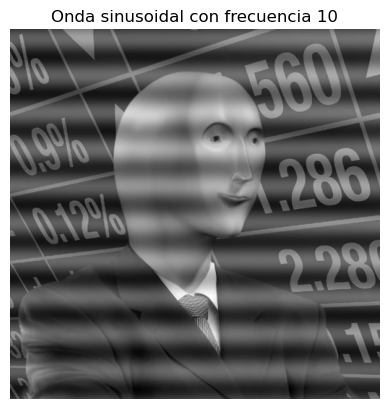

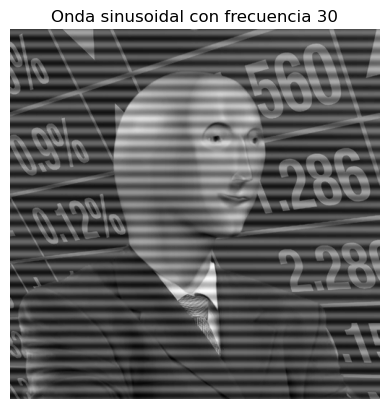

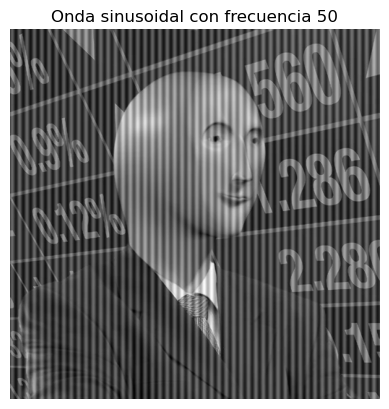

In [163]:
import numpy as np
import numpy.matlib

# La imagen A ya es escala de grises y tipo uint8
gray = A.astype(np.float32)
gray = cv2.normalize(gray, dst=None, alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX)

frec = {10,30,50} # Frecuencia de la onda sinusoidal
#vamos a crear ruido
def makenoise(gray, frec, orientation=0):
    if orientation == 1:
        # Ruido vertical: la onda varía a lo largo de las filas
        V = np.linspace(0, 1, num=gray.shape[0])
        Y = 0.2 * np.sin(2 * np.pi * frec * V)
        M = np.matlib.repmat(Y, gray.shape[1], 1).T
    else:
        # Ruido horizontal: la onda varía a lo largo de las columnas
        V = np.linspace(0, 1, num=gray.shape[1])
        Y = 0.2 * np.sin(2 * np.pi * frec * V)
        M = np.matlib.repmat(Y, gray.shape[0], 1)
    noise_img = np.add(M, gray)
    return noise_img

# Mostrar las imágenes ruidosas en orden de frecuencia
noised_images = []
for f in sorted(frec):
    if f != 50:
        noise_img = makenoise(gray, f, 1)
    else:
        noise_img = makenoise(gray, f)
    plt.imshow(noise_img, cmap='gray')
    plt.title(f'Onda sinusoidal con frecuencia {f}')
    plt.axis('off')
    plt.show()
    noised_images.append(noise_img)



Para realizar la tarea se obtuvo el espectro estelar de la imagen en el dominio de la frecuencia y se aplicaron filtros para atenuar el ruido en diferentes bandas de frecuencia en el espectro.

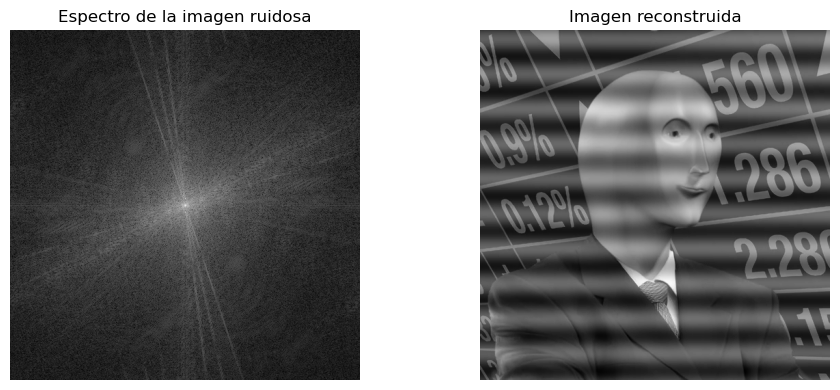

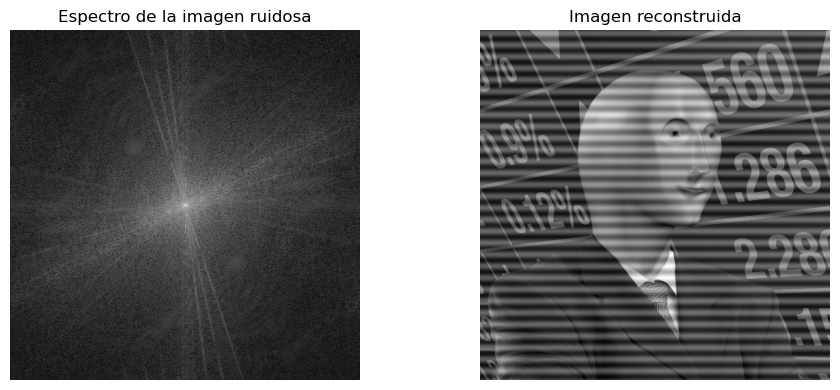

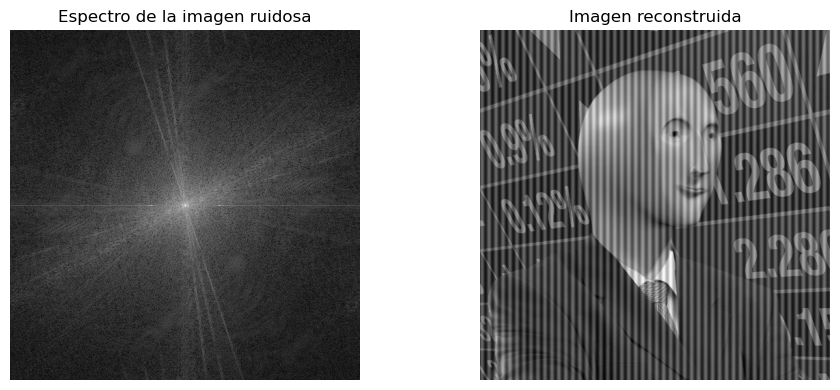

In [164]:
def get_star_spectrum(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    return fshift

def starreturn(star):
    f_ishift = np.fft.ifftshift(star)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.real(img_back)
    img_back = cv2.normalize(img_back, dst=None, alpha=0.0, beta=1.0, norm_type=cv2.NORM_MINMAX)
    return img_back


# Mostrar el espectro y la imagen reconstruida lado a lado para cada imagen ruidosa
for i in noised_images:
    spectrum = get_star_spectrum(i)
    img_back = starreturn(spectrum)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(np.log(1 + np.abs(spectrum)), cmap='gray')
    axs[0].set_title('Espectro de la imagen ruidosa')
    axs[0].axis('off')
    axs[1].imshow(img_back, cmap='gray')
    axs[1].set_title('Imagen reconstruida')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()


El código aplica un filtro en el dominio de la frecuencia para eliminar ruido periódico en imágenes. 
Utiliza la transformada de Fourier y una máscara para bloquear frecuencias específicas según orientación y valor. 
Finalmente, reconstruye y muestra las imágenes filtradas para comparar la mejora visual.

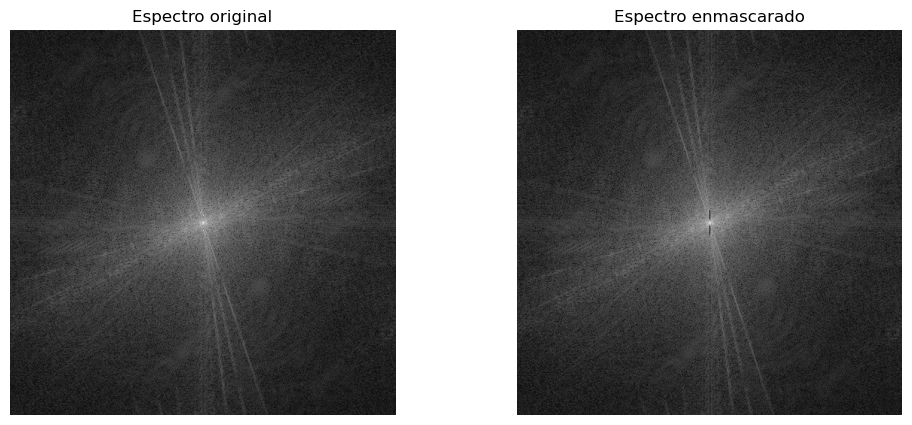

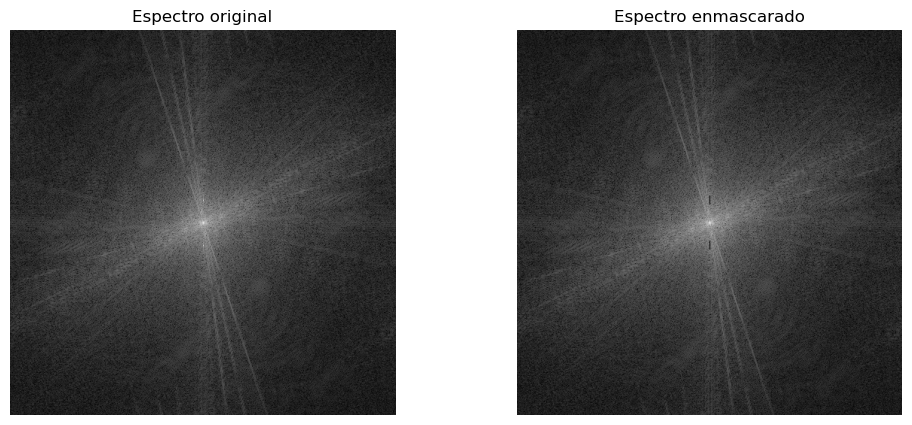

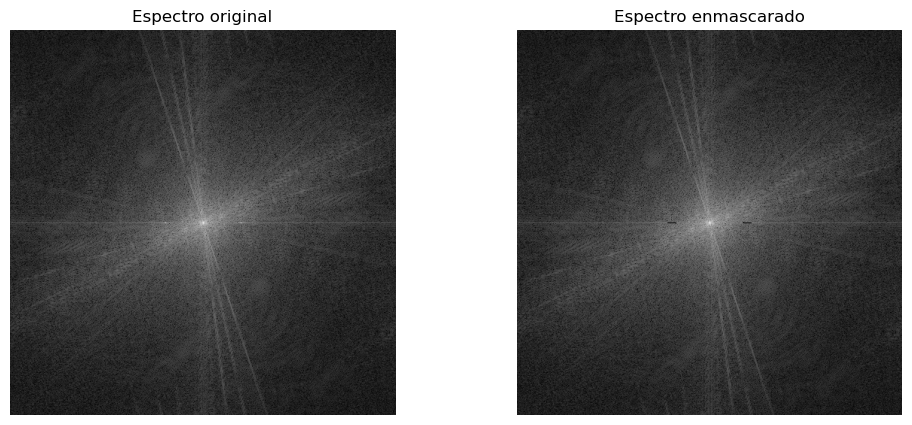

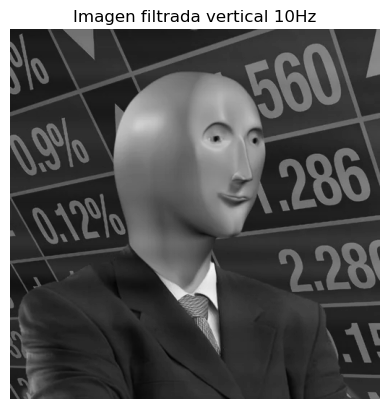

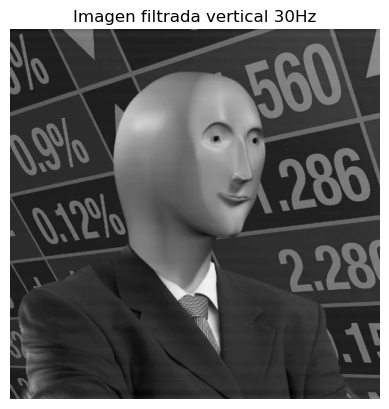

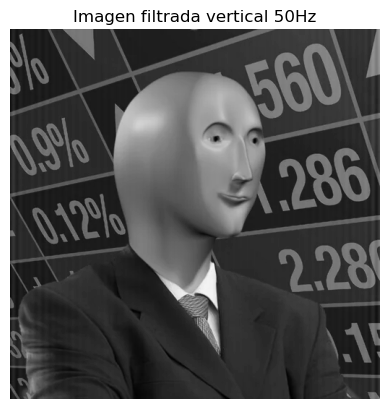

In [165]:

# Selecciona la imagen ruidosa que quieres filtrar, por ejemplo noised_images[0] para 10Hz
def filtrar_ruido_frecuencial(img_ruido, frec, radius=6, orientation=0):
    # Obtener el espectro de Fourier
    Fshift = get_star_spectrum(img_ruido)
    # Crear una máscara para bloquear los picos de ruido
    mask = np.ones_like(Fshift, dtype=np.float32)
    rows, cols = mask.shape
    crow, ccol = rows // 2, cols // 2

    if orientation == 1:
        # Ruido vertical: picos a +/-frec en eje vertical (filas)
        for f in [frec, -frec]:
            mask[crow + f - radius:crow + f + radius, ccol] = 0
            mask[crow - f - radius:crow - f + radius, ccol] = 0
    else:
        # Ruido horizontal: picos a +/-frec en eje horizontal (columnas)
        for f in [frec, -frec]:
            mask[crow, ccol + f - radius:ccol + f + radius] = 0
            mask[crow, ccol - f - radius:ccol - f + radius] = 0

    # Mostrar el espectro antes y después de la máscara
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(np.log(1 + np.abs(Fshift)), cmap='gray')
    plt.title('Espectro original')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(np.log(1 + np.abs(Fshift * mask)), cmap='gray')
    plt.title('Espectro enmascarado')
    plt.axis('off')
    plt.show()

    # Aplicar la máscara y reconstruir la imagen
    Fshift_filtered = Fshift * mask
    out = starreturn(Fshift_filtered)
    return out

# Ejemplo de uso:
out = []
# Filtrar las imágenes ruidosas de 10, 30 y 50 Hz en orientación vertical
# Asegúrate de que las frecuencias estén en orden para coincidir con noised_images
frec_list = sorted(list(frec))
for i, f in enumerate(frec_list):
    orientation = 0 if f == 50 else 1
    filtered_img = filtrar_ruido_frecuencial(noised_images[i], f, orientation=orientation)
    out.append(filtered_img)

# Mostrar las imágenes filtradas
for i, f in enumerate(frec_list):
    plt.imshow(out[i], cmap='gray')
    plt.title(f'Imagen filtrada vertical {f}Hz')
    plt.axis('off')
    plt.show()
    

Como es posible observar, se generaron imágenes con ruido frecuencial a diferentes frecuencias (10Hz, 30Hz y 50Hz) y se aplicaron filtros para atenuar dicho ruido. Si bien los filtros no logran eliminar completamente el ruido, sí logran reducirlo significativamente, mejorando la calidad visual de las imágenes resultantes.

## Parte 2
A partir del código proporcionado, se generó una imagen con ruido.

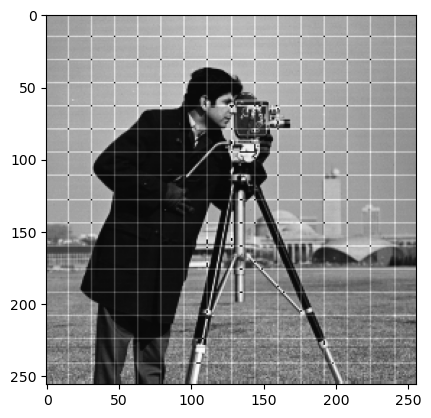

In [146]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('cameraman.png',cv2.IMREAD_GRAYSCALE)
m = img.shape[0]
delta = 15
V = np.fix(np.linspace(delta,m-delta,delta)).astype('uint8')
img[V,:] = img[V,:]+50
img[:,V] = img[:,V]+50
plt.imshow(img, cmap='gray')
plt.show()

Los filtros aplicados fueron diseñados para reducir el ruido pimienta, que es un tipo de ruido que se manifiesta como puntos oscuros en la imagen. Para hacer eso se utilizó un filtro mediano que es efectivo para este tipo de ruido. 
Luego se le aplicó un filtro notch selectivo para eliminar el ruido en el dominio de la frecuencia.
Finalmente se le aplico otro filtro más, un filtro morfologico que permite eliminar los restos de ruido que quedan en la imagen después de aplicar el filtro notch.


In [147]:
def quitar_sal_pimienta(img, kernel_size=3):
    """
    Filtro mediano para eliminar ruido sal y pimienta.
    """
    return cv2.medianBlur(img, kernel_size)

def filtro_notch_selectivo(img, radio_notch=4, umbral_percentil=99.6):
    """
    Filtro notch selectivo en el dominio de la frecuencia.
    """
    fft = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft)
    espectro = np.abs(fft_shift)

    filas, columnas = img.shape
    centro_fila, centro_col = filas // 2, columnas // 2

    umbral = np.percentile(espectro, umbral_percentil)
    picos = espectro > umbral

    y, x = np.ogrid[:filas, :columnas]
    centro_mask = (x - centro_col)**2 + (y - centro_fila)**2 <= 35**2
    picos[centro_mask] = False

    mascara = np.ones_like(fft_shift, dtype=bool)
    picos_coords = np.where(picos)
    for py, px in zip(*picos_coords):
        yy, xx = np.ogrid[:filas, :columnas]
        circulo = (xx - px)**2 + (yy - py)**2 <= radio_notch**2
        mascara[circulo] = False

    fft_filtrado = fft_shift * mascara
    fft_ishift = np.fft.ifftshift(fft_filtrado)
    img_filtrada = np.abs(np.fft.ifft2(fft_ishift))
    return np.clip(img_filtrada, 0, 255).astype(np.uint8)

def filtro_morfologico(img, kernel_size=3):
    """
    Filtro morfológico (apertura + cierre) para limpiar estructuras pequeñas.
    """
    img_median = cv2.medianBlur(img, kernel_size)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    img_open = cv2.morphologyEx(img_median, cv2.MORPH_OPEN, kernel)
    img_close = cv2.morphologyEx(img_open, cv2.MORPH_CLOSE, kernel)
    return img_close


Se utilizaron métodos combinados para eliminar el ruido generado, aplicando un filtro notch en el dominio de la frecuencia junto con un filtro morfológico en el dominio espacial. Esta combinación permitió reducir el ruido periódico manteniendo la estructura de la imagen.
Se elimino la pimienta.

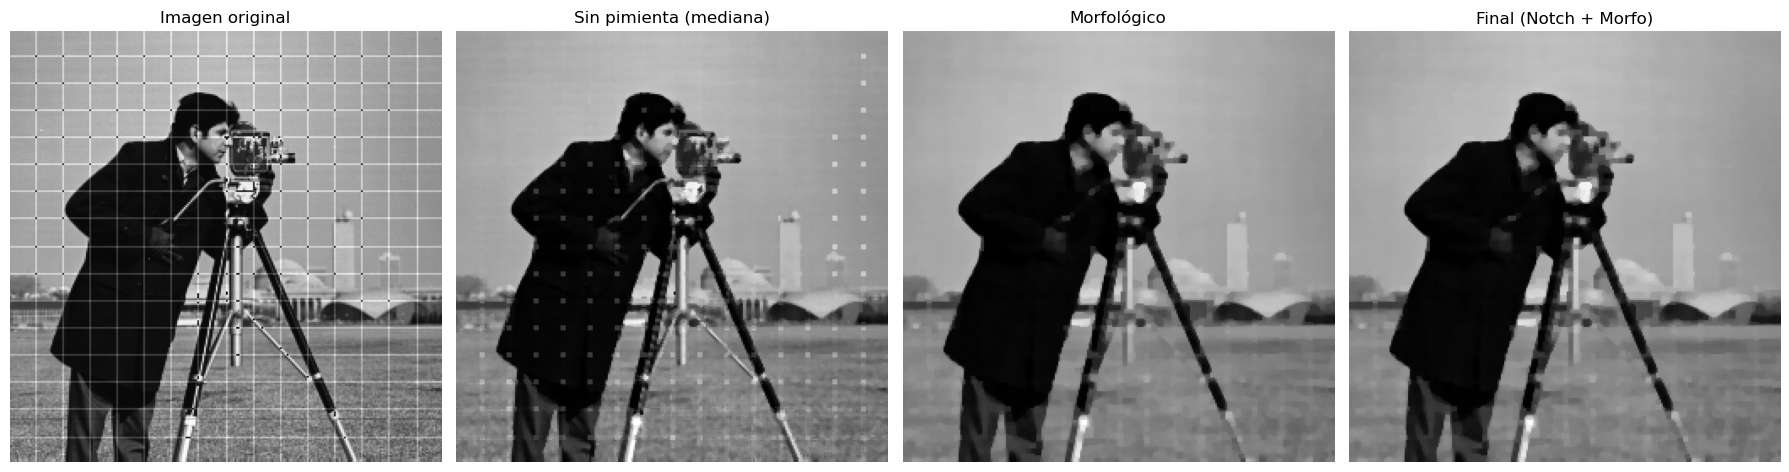

In [ ]:
img_sinpimienta = quitar_sal_pimienta(img, kernel_size=3)
img_notch1 = filtro_notch_selectivo(img_sinpimienta)
img_morfo = filtro_morfologico(img_notch1, kernel_size=3)
img_notch_final = filtro_notch_selectivo(img_morfo)

plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis('off')


plt.subplot(1, 4, 2)
plt.imshow(img_sinpimienta, cmap='gray')
plt.title("Sin pimienta (mediana)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_morfo, cmap='gray')
plt.title("Morfológico")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_notch_final, cmap='gray')
plt.title("Final (Notch + Morfo)")
plt.axis('off')

plt.tight_layout()
plt.show()





## Anexos

Utilizando un blur y un aumento de pesos se logra mejorar ligeramente la imagen, pero no es suficiente para eliminar el ruido completamente. 

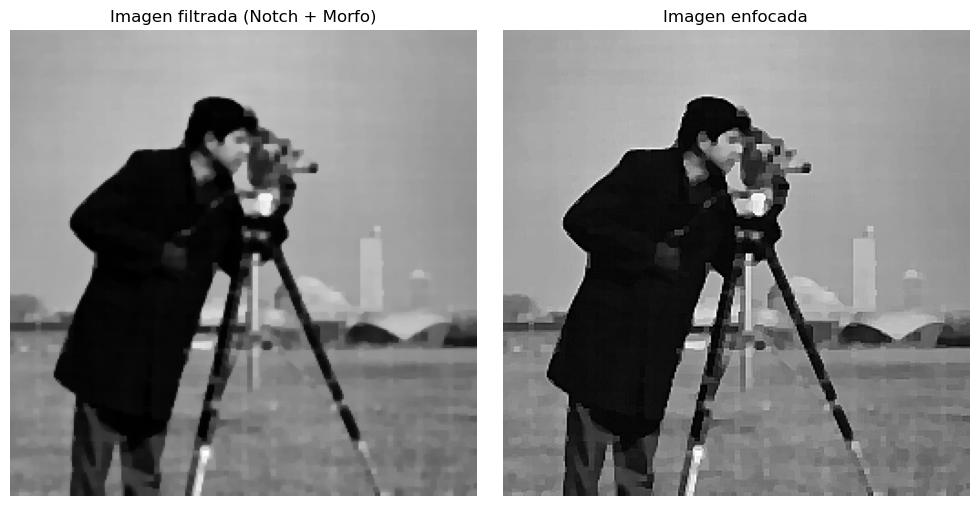

In [ ]:
def enfocar_imagen(img, ksize=3, alpha=1.5):

    img_blur = cv2.GaussianBlur(img, (ksize, ksize), 0)
    sharpened = cv2.addWeighted(img, 1 + alpha, img_blur, -alpha, 0)
    return sharpened

img_enfocada = enfocar_imagen(img_notch_final, ksize=3, alpha=1.5)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_notch_final, cmap='gray')
plt.title('Imagen filtrada (Notch + Morfo)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_enfocada, cmap='gray')
plt.title('Imagen enfocada')
plt.axis('off')

plt.tight_layout()
plt.show()



Si bien los filtros logran reducir significativamente el ruido, no logran eliminarlo por completo. También es posible observar que a partir del filtro morfologico se empiezan a perder detalles de la imagen original, lo que es un efecto secundario no deseado al aplicar filtros para eliminar ruido.
Hay que recalcar que estos filtros siempre llevarán a una aproximación de la imagen original y no a una solución perfecta, ya que el ruido puede variar en su naturaleza y características.


